In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cv2
import numpy as np
import glob
import datetime as dt
from itertools import repeat

import scipy.stats as stat

import sys
sys.path.append("./libraries")
import cloud_processing_lib as cpl

from concurrent.futures import ThreadPoolExecutor

In [19]:
#init input

year = "2026"
month = "04"
day = "10"

# root_path = "/home/sdoeding/testflow_images/"     #for test flow
# glob_query = root_path + "*.png"

root_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/"
glob_query = root_path + "{0}/{1}/{2}/**/*.png".format(year,month,day)

path_collector = glob.glob(glob_query, recursive=True)
path_collector.sort()

timestamps = []
for path in path_collector:
   timestamps.append(dt.datetime.strptime(path[-19:-4], "%Y%m%d_%H%M%S"))

images_n = len(path_collector)

In [20]:
def append_frame(path1, path2, mappings, mask):

    frame1 = cv2.imread(path1, -1)
    frame1 = cv2.demosaicing(frame1, cv2.COLOR_BAYER_BGGR2GRAY)
    frame1 = cv2.resize(frame1, (1520, 1520), interpolation=cv2.INTER_AREA)
    frame1 = cv2.remap(frame1, mappings[1], mappings[0], interpolation=cv2.INTER_LINEAR)
    
    frame2 = cv2.imread(path2, -1)
    frame2 = cv2.demosaicing(frame2, cv2.COLOR_BAYER_BGGR2GRAY)
    frame2 = cv2.resize(frame2, (1520, 1520), interpolation=cv2.INTER_AREA)
    frame2 = cv2.remap(frame2, mappings[1], mappings[0], interpolation=cv2.INTER_LINEAR)

    flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    mag = np.where(mask[:,:,0]<1, np.nan, mag)
    ang = np.where(mask[:,:,0]<1, np.nan, ang)

    ang = np.where(mag<1, np.nan, ang)
    mag = np.where(mag<1, np.nan, mag)

    # histdata = np.histogram(ang[~np.isnan(ang)], bins=500, density=True)
    # print(mag)
    # plt.figure()
    # plt.plot(histdata[1][:-1],histdata[0])
    # plt.savefig("test.png")
    
    hsv_mask = np.zeros((1520, 1520, 3), dtype="uint8")
    hsv_mask[..., 1] = 255
    hsv_mask[..., 0] = ang * 180 / np.pi / 2
    hsv_mask[..., 2] = mag

    #hsv_mask[..., 2] = cv2.normalize(hsv_mask[..., 2], None, 0, 255, cv2.NORM_MINMAX)
    hsv_mask[..., 2] = np.clip(hsv_mask[..., 2] / 25 * 255, 0, 255)
    
    rgb_representation = cv2.cvtColor(hsv_mask, cv2.COLOR_HSV2BGR)
    rgb_representation = cv2.putText(rgb_representation, path2[-10:], (0, 1460), cv2.FONT_HERSHEY_DUPLEX, 0.6, (80,80,80),2)
    rgb_representation = cv2.putText(rgb_representation, str(np.nanmean(mag)), (0, 1480), cv2.FONT_HERSHEY_DUPLEX, 0.6, (80,80,80),2)
    rgb_representation = cv2.putText(rgb_representation, str(np.rad2deg(stat.circmean(ang, nan_policy="omit"))), (0, 1500), cv2.FONT_HERSHEY_DUPLEX, 0.6, (80,80,80),2)
      
    #mag_collector.append(np.nanmedian(mag))
    mag_collector.append(np.nanmean(mag))
    mag_std_collector.append(np.nanstd(mag))
    dir_collector.append(stat.circmean(ang, nan_policy="omit"))
    dir_std_collector.append(stat.circstd(ang, nan_policy="omit"))

    return rgb_representation, flow #please delete flow

In [21]:
video_data = cv2.VideoWriter("flow_out.mp4", cv2.VideoWriter_fourcc('m','p','4','v'), 30, (1520, 1520))

counter = 0
start_time = dt.datetime.now()

mappings = cpl.calc_mappings(95,80,1520,"equidistant")

if int(month) > 4:
    mask = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_new.png")
else:
    mask = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_old.png")
    
mask = cv2.remap(mask, mappings[1], mappings[0], interpolation=cv2.INTER_LINEAR)

mag_collector = []
mag_std_collector = []
dir_collector = []
dir_std_collector = []

with ThreadPoolExecutor(max_workers=16) as executor:
    for res in executor.map(append_frame, path_collector[1:], path_collector[:-1], repeat(mappings), repeat(mask)):

        counter += 1

        progress_percent = np.round(counter/images_n * 100, 3)
        runtime_sec = (dt.datetime.now() - start_time).seconds
        
        print("Running {3:02d}:{4:02d} - {0} of {1} images processed ({2:.3f} %)".format(counter, images_n, progress_percent, 
                                                                                 runtime_sec // 60, runtime_sec % 60), end="\r")
        video_data.write(res[0])

stop_time = dt.datetime.now()
runtime_sec = (stop_time - start_time).seconds

video_data.release()
cv2.destroyAllWindows()

print("Done")

/tmp/ipykernel_3052336/3531010681.py:31: RuntimeWarning: invalid value encountered in cast
  hsv_mask[..., 0] = ang * 180 / np.pi / 2
/tmp/ipykernel_3052336/3531010681.py:32: RuntimeWarning: invalid value encountered in cast
  hsv_mask[..., 2] = mag


Doneing 01:48 - 1732 of 1733 images processed (99.942 %)


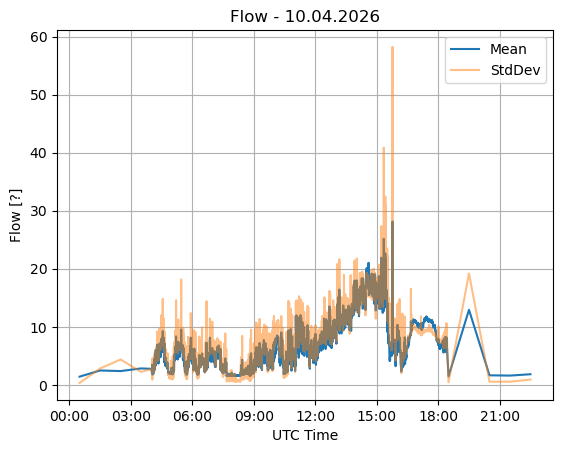

In [22]:
plt.plot(timestamps[:-1],mag_collector, label="Mean")
plt.plot(timestamps[:-1],mag_std_collector, alpha=0.5, label="StdDev")
plt.title("Flow - {0}.{1}.{2}".format(day,month,year))
plt.xlabel("UTC Time")
plt.ylabel("Flow [?]")
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
plt.grid()
plt.legend()

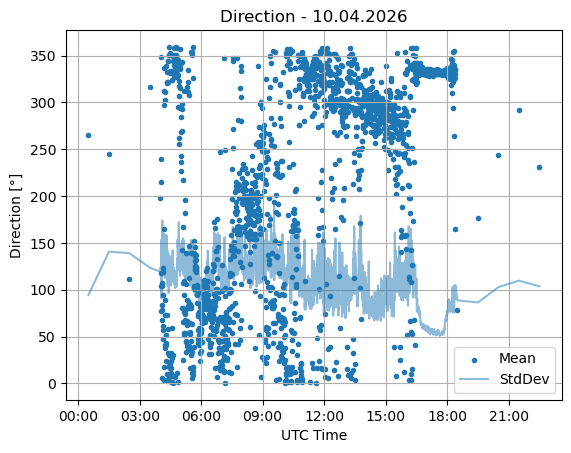

In [23]:
plt.scatter(timestamps[:-1], np.array(dir_collector)* 180 / np.pi, label="Mean", marker=".")
plt.plot(timestamps[:-1], np.array(dir_std_collector)* 180 / np.pi, label="StdDev", alpha=0.5)
plt.title("Direction - {0}.{1}.{2}".format(day,month,year))
plt.xlabel("UTC Time")
plt.ylabel("Direction [°]")
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
#plt.ylim(0,360)
plt.grid()
plt.legend()

In [24]:
print(np.max(np.array(dir_collector) * 180 / np.pi))
print(np.min(np.array(dir_collector) * 180 / np.pi))

359.22794
0.5914519


/tmp/ipykernel_3052336/3531010681.py:31: RuntimeWarning: invalid value encountered in cast
  hsv_mask[..., 0] = ang * 180 / np.pi / 2
/tmp/ipykernel_3052336/3531010681.py:32: RuntimeWarning: invalid value encountered in cast
  hsv_mask[..., 2] = mag


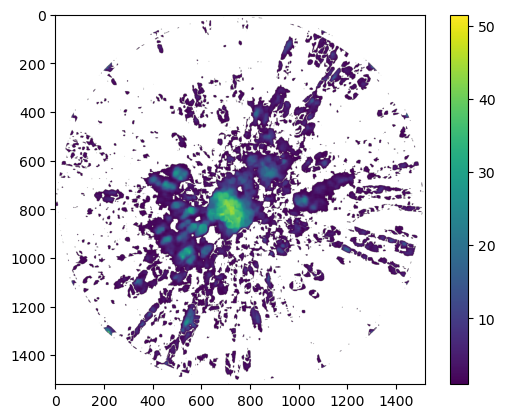

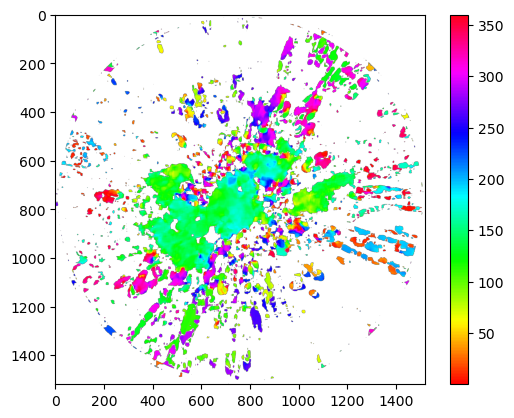

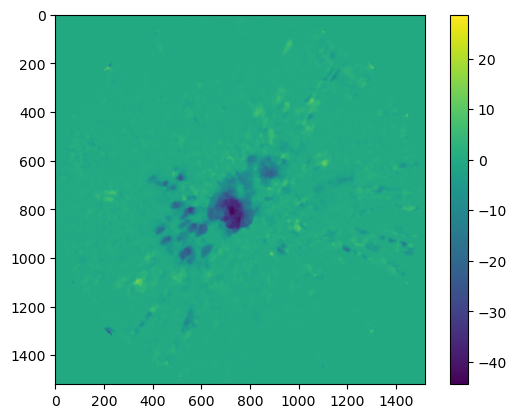

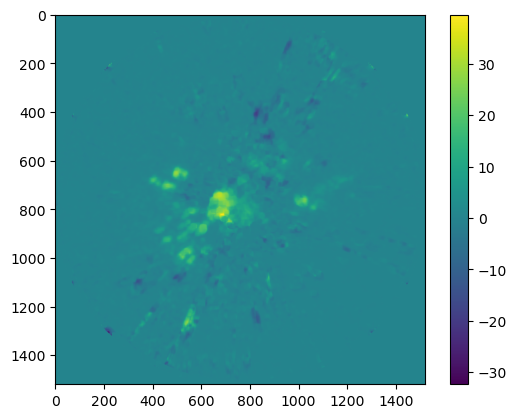

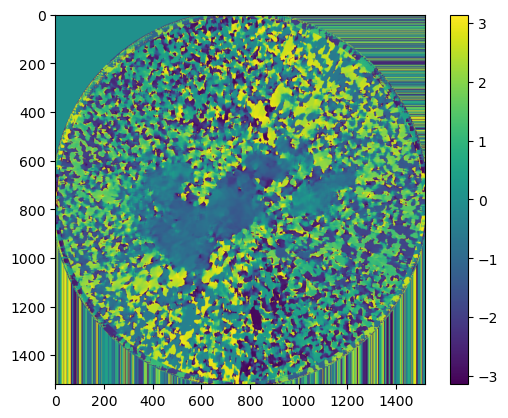

In [25]:
testreturn = append_frame(path_collector[900], path_collector[901], mappings, mask)
mag, ang = cv2.cartToPolar(testreturn[1][...,0], testreturn[1][..., 1])

ang = np.where(mag<1, np.nan, ang)
mag = np.where(mag<1, np.nan, mag)

plt.figure()
plt.imshow(mag)
plt.colorbar()

plt.figure()
plt.imshow(np.rad2deg(ang), cmap="hsv")
plt.colorbar()


plt.figure()
plt.imshow(testreturn[1][...,0])
plt.colorbar()

plt.figure()
plt.imshow(testreturn[1][...,1])
plt.colorbar()

plt.figure()
plt.imshow(np.atan2(testreturn[1][...,0], testreturn[1][...,1]))
plt.colorbar()

